# 2 - Training U-Net for Gap-Filling (Generic - Streaming)

**Self-supervised streaming training pipeline** for any Level-3 ocean variable.

This notebook trains a U-Net to fill gaps in satellite ocean observations using **xbatcher streaming** to keep memory bounded. Works for:
- Chlorophyll-a (PACE, Copernicus, CMEMS)
- Sea surface temperature
- Any other gridded ocean variable with cloud/missing data

## Key Features

- **Streaming workflow**: Zarr → xarray/Dask → xbatcher → TensorFlow
- **Memory-bounded**: Never loads full dataset into RAM
- **Spatial chunking**: 40×56 tiles (or configurable)
- **Generic target variable**: Not hardcoded to chlorophyll
- **Self-supervised**: No gap-free truth needed  
- **Synthetic clouds**: Temporally-correlated fake gaps for training/eval

## Workflow

```
Zarr (on-disk)
  ↓ xr.open_zarr with chunks
Lazy xarray/Dask Dataset
  ↓ build_standardized_lazy (no .load())
Lazy standardized channels
  ↓ xbatcher.BatchGenerator
Spatial tiles (time × 40×56)
  ↓ make_tf_gen → tf.data.Dataset
Training batches
  ↓
model.fit()
```

## Setup

In [5]:
%pip install -e ..

%load_ext autoreload
%autoreload 2

import mindthegap as mtg
print(mtg.__file__)

Obtaining file:///home/jovyan/mindthegap
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for mindthegap (pyproject.toml) ... done
  Created wheel for mindthegap: filename=mindthegap-0.2.0-0.editable-py3-none-any.whl size=5701 sha256=a73d4d4d18da81ecbb7199acd65c7388e71f4f47f69b90302aba6f41c052beb4
  Stored in directory: /tmp/pip-ephem-wheel-cache-8akmanjw/wheels/bf/33/56/bda8a265cbf6abb8b49f20ef4e8f99a5cafc428b704405201e
Successfully built mindthegap
  Attempting uninstall: mindthegap
    Found existing installation: mindthegap 0.1.0
    Uninstalling mindthegap-0.1.0:
      Successfully uninstalled mindthegap-0.1.0
Note: you may need to restart the kernel to use updated packages.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/srv/conda/envs/notebook/lib/python3.12/site

In [1]:
# Import the local checkout when running this notebook from the repository.
dataset = "globcolour"  # pace, globcolour, indian-ocean, or synthetic
region = "arabian sea"  # or [lat_min, lat_max, lon_min, lon_max]
time_slice = None

dataset = "indian-ocean"  # pace, globcolour, indian-ocean, or synthetic
region = "indian ocean"  # or [lat_min, lat_max, lon_min, lon_max]
time_slice = slice("01-01-2000", "12-31-2000")

dataset = "io-shared-public"  # pace, globcolour, indian-ocean, or synthetic
region = "indian ocean"  # or [lat_min, lat_max, lon_min, lon_max]
time_slice = slice("01-01-2000", "12-31-2000")


# SMOKE_TEST keeps the whole run small and fast: demo_data returns a small
# subset and options caps training to 2 epochs. Set False for a full run.
SMOKE_TEST = False


### packages

In [3]:
!pip install -qU "icechunk>=2" "earthaccess>=0.15"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
awscli 1.45.58 requires botocore==1.43.58, but you have botocore 1.40.70 which is incompatible.
boto3 1.43.67 requires botocore<1.44.0,>=1.43.67, but you have botocore 1.40.70 which is incompatible.


In [4]:
!pip install -qU boto3 botocore s3transfer

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
awscli 1.45.58 requires botocore==1.43.58, but you have botocore 1.43.67 which is incompatible.
aiobotocore 2.25.2 requires botocore<1.40.71,>=1.40.46, but you have botocore 1.43.67 which is incompatible.


### GPU set up

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # Reduce TensorFlow verbosity

import numpy as np
import pandas as pd
import xarray as xr
import tensorflow as tf
import matplotlib.pyplot as plt
import mindthegap as mtg

# TensorFlow automatically uses CPU when no GPU is available.
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print(f"TensorFlow version: {tf.__version__}")
print(f"Compute device: {'GPU' if gpus else 'CPU'}")
print(f"GPUs available: {len(gpus)}")

2026-08-09 05:25:32.905591: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786253132.924740   15851 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786253132.931076   15851 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786253132.945700   15851 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786253132.945718   15851 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786253132.945720   15851 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.1
Compute device: GPU
GPUs available: 1


## 1. Load Your Data

Load your xarray Dataset with **time, lat, lon** dimensions.

### Requirements:
- Target variable (e.g., `chlor_a`, `sst`, `analysed_sst`)
- Cloud/missing flag variable (1 = cloud/missing, 0 = valid data)
- Land flag variable (1 = land, 0 = ocean)
- Optional: Additional predictor variables (SST, winds, salinity, etc.)

### Data Source Examples:

In [3]:
# Load the data. When SMOKE_TEST is set, demo_data returns a small subset.
ds, data_metadata = mtg.demo_data(
    dataset=dataset,
    region=region,
    time_slice=time_slice,
    smoke_test=SMOKE_TEST,
)
print(f"Selected dataset: {data_metadata['dataset']['name']}")
print(f"Dimensions: {dict(ds.sizes)}")


Selected dataset: IO rechunkded in shared-public
Dimensions: {'time': 365, 'lat': 169, 'lon': 241}


## 2. Build Standardized Training data

Use `build_standardized_lazy()` to create standardized predictors **without loading data into memory**.

In [4]:
# Crop to U-Net-compatible dimensions (multiples of 8).
ds = mtg.crop_to_multiple(ds, multiple=8)

print(f"\nAfter cropping to multiple of 8:")
print(f"Dimensions: {dict(ds.sizes)}")



After cropping to multiple of 8:
Dimensions: {'time': 365, 'lat': 168, 'lon': 240}


In [5]:
# Pipeline configuration. Options is the single, canonical config for this run.
# smoke_test propagates the fast-run settings (few epochs) into options.fit.
options = mtg.Options.default(smoke_test=SMOKE_TEST)

# log-transform CHL since it is 0-bounded (set False for e.g. SST).
options.data.log_target = True

# Resolve all data-dependent configuration from the (cropped) dataset and its
# loader metadata in one call. The train/validation split is chosen separately,
# below, so it is not set here. The functions below print progress when
# options.verbose is True (the default); set options.verbose = False to quiet them.
options.set_data_config(data=ds, metadata=data_metadata)

print(options)


Options(
  gridder:
    method = 'xbatcher'
    tile_size = (64, 64)
    overlap = None
    time_chunk = 60
    preload_batch = False
    tile_upper_limit = 64
    tile_multiple = 8
  fit:
    epochs = 50
    batch_size = 8
    learning_rate = 0.001
    patience = 10
    loss = 'mse'
    optimizer = 'adam'
    shuffle_buffer = 512
    pixel_budget = 35840
    shuffle_seed = None
    tf_seed = None
  split:
    method = 'random'
    train_fraction = 0.8
    val_fraction = 0.2
    train_dates = []
    val_dates = []
    min_day_difference = 1
    seed = None
  data:
    source = 'IO rechunkded in shared-public'
    product_id = 'shared-public/IO_rechunked.zarr'
    lat_bounds = (-11.75, 30.0)
    lon_bounds = (42.0, 101.75)
    target = None
    target_name = 'CHL_cmes-level3'
    target_units = 'milligram m-3'
    target_variable = 'CHL_cmes-level3'
    missing_flag = 'CHL_cmes-cloud'
    land_flag = 'CHL_cmes-land'
    features = []
    log_target = True
    n_temporal_lags = 1
    add

## Training and validation dates

Select the dates to use for training and validation

In [6]:
# Choose the training and validation dates. Passing the full options object
# lets the function read the split configuration (options.split.method, the
# train/validation fractions default 80/20, etc.) and resolve the seed from
# options. It records the selected dates on options.split.
#
# For fixed windows instead, set options.split.method = "manual" and pass
# train_slice / val_slice:
#   options.split.method = "manual"
#   mtg.train_validation_dates(
#       ds.time, options,
#       train_slice=slice("1997-01-01", "2000-01-01"),
#       val_slice=slice("2000-01-02", "2001-01-01"),
#   )

# Seeds. options.seed is the single global seed and defaults to a random
# integer drawn once (so runs are random by default but reproducible after
# the fact, since the value is recorded when the model is saved). Set it to a
# fixed integer for a deterministic run, e.g. options.seed = 42.
#
# Per-stage seeds default to None and inherit the global seed:
#   options.split.seed       -> train/validation date sampling
#   options.fit.shuffle_seed -> tf.data shuffling
# Assign an explicit integer to vary just that stage independently.
#
# TensorFlow's global RNG (weight init) is NOT seeded automatically. For a
# fully deterministic run also call options.seed_tensorflow(options.seed)
# before building the model.
mtg.train_validation_dates(ds.time, options)


Split method: random (train=292, val=73 dates)
Training period: 2000-01-02 to 2000-12-31


Options(
  gridder:
    method = 'xbatcher'
    tile_size = (64, 64)
    overlap = None
    time_chunk = 60
    preload_batch = False
    tile_upper_limit = 64
    tile_multiple = 8
  fit:
    epochs = 50
    batch_size = 8
    learning_rate = 0.001
    patience = 10
    loss = 'mse'
    optimizer = 'adam'
    shuffle_buffer = 512
    pixel_budget = 35840
    shuffle_seed = None
    tf_seed = None
  split:
    method = 'random'
    train_fraction = 0.8
    val_fraction = 0.2
    train_dates = ['2000-01-02', '2000-01-04', '2000-01-05', '2000-01-06', '2000-01-07', '2000-01-08', '2000-01-09', '2000-01-10', '2000-01-11', '2000-01-12', '2000-01-14', '2000-01-15', '2000-01-16', '2000-01-17', '2000-01-18', '2000-01-19', '2000-01-21', '2000-01-22', '2000-01-24', '2000-01-25', '2000-01-26', '2000-01-27', '2000-01-28', '2000-01-29', '2000-01-30', '2000-01-31', '2000-02-01', '2000-02-02', '2000-02-03', '2000-02-04', '2000-02-05', '2000-02-06', '2000-02-07', '2000-02-08', '2000-02-10', '2000-02-11

## Build lazy standardized dataset

* add n-prev and n-next targets as inputs
* add features (optional) as inputs; standardize
* add flags (land, real cloud, fake cloud)
* rename the target; standardize and log (optional)

In [7]:
# Build the lazy, standardized training dataset. Everything it needs -- variable
# names, features, log-transform, temporal lags, add_geo, output chunking, and
# the training dates for computing standardization statistics -- comes from the
# options object. options.data is populated in place with the resolved channel
# order, standardization, and target mean/std.
#
# To add spherical lat/lon features, set options.data.add_geo = True first.
ds_std, stats = mtg.build_standardized_lazy(ds, options)


Channels created (9 total):
  1. masked_target
  2. masked_target_m1
  3. masked_target_p1
  4. day_sin
  5. day_cos
  6. synthetic_missing_flag
  7. true_missing_flag
  8. valid_masked_target_flag
  9. land_flag
Target standardization: mean=0.0000, std=1.0000
Dataset is LAZY (not in memory): Frozen({'time': (60, 60, 60, 60, 60, 60, 5), 'lat': (64, 64, 40), 'lon': (64, 64, 64, 48)})


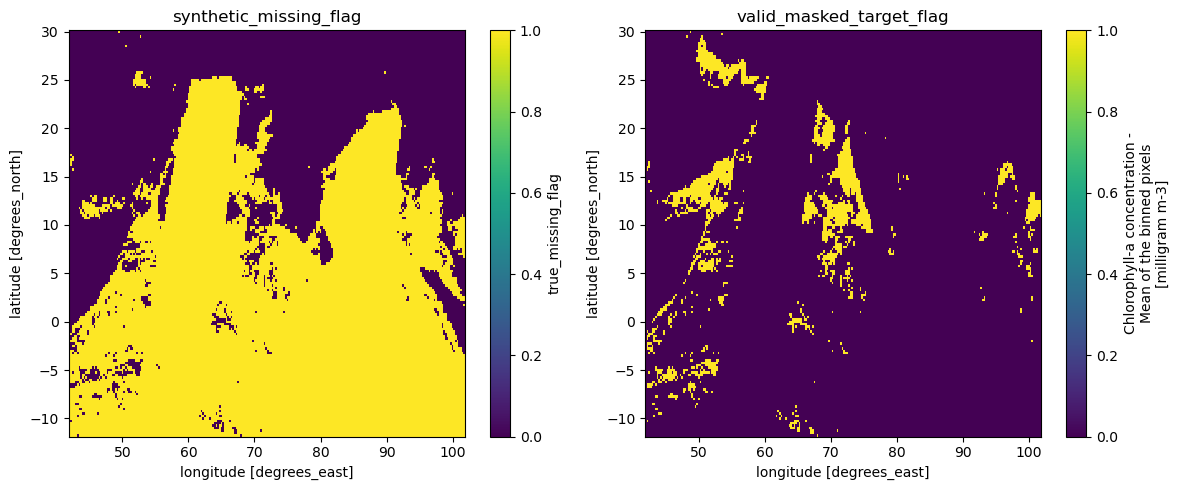

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ds_std.true_missing_flag.isel(time=0).plot(ax=axes[0])
axes[0].set_title("synthetic_missing_flag")

ds_std.valid_masked_target_flag.isel(time=0).plot(ax=axes[1])
axes[1].set_title("valid_masked_target_flag")

plt.tight_layout()

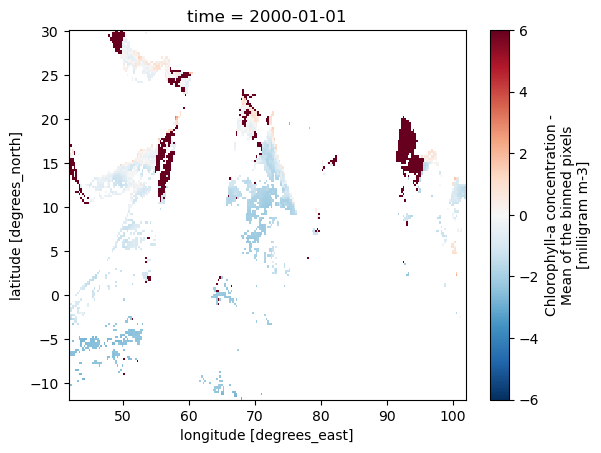

In [37]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np

da = (
    ds_std.full_target
    * ds_std.valid_masked_target_flag
    + ds_std.synthetic_missing_flag*6
).isel(time=0)

da.plot()

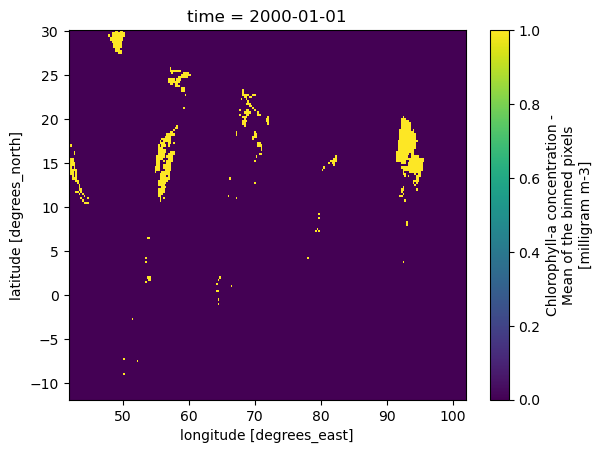

In [40]:
mask = (
    ds_std.synthetic_missing_flag
    & ~ds_std.valid_masked_target_flag
)

mask.isel(time=0).plot()

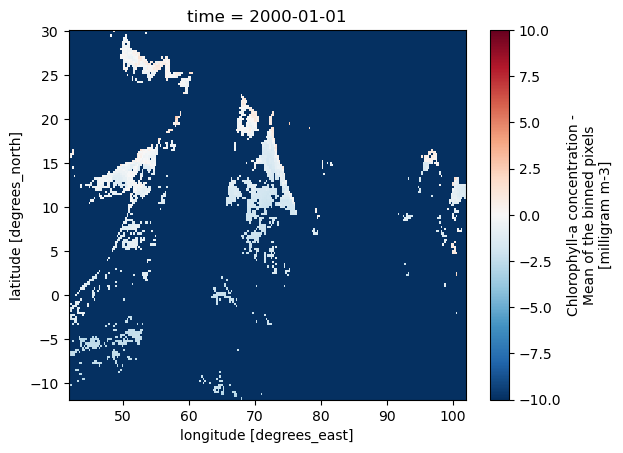

In [27]:
da = ds_std.full_target.isel(time=0).where(
    ds_std.valid_masked_target_flag.isel(time=0) == 1,
    other=-10,
)

da.plot()

## 3. Create xbatcher Streaming Pipeline

Use `mtg.make_xbatcher()` to create tile generators, then wrap with `mtg.make_tf_gen()` for TensorFlow.

In [8]:
# Build the streaming train/validation TensorFlow datasets in one call.
# make_generator splits ds_std using options.split, tiles with options.gridder,
# reads the channel order/target from options.data, and batches with
# options.fit. It returns the datasets and the steps-per-epoch.
train_dataset, val_dataset, train_steps, val_steps = mtg.make_generator(
    ds_std,
    options,
)


Streaming datasets ready (batch size 8): steps per epoch train=180, val=45


## 4. Build U-Net Model

Fully-convolutional U-Net that can accept any spatial size (trains on 40×56, can predict on full domain).

In [9]:
# Build U-Net (fully-convolutional). The channel count comes from the resolved
# configuration; compilation is handled by mtg.fit_model using options.fit.
# mtg.UNet prints its input/output shapes and channel order when verbose,
# controlled by the global options.verbose.
num_channels = len(options.data.input_names)
model = mtg.UNet(
    (None, None, num_channels),
    verbose=options.verbose,
    tile_size=options.gridder.tile_size,
    input_names=options.data.input_names,
)

# model.summary()



Model input shape: (batch, 64, 64, 9)
Model output shape: (batch, 64, 64, 1)

Input names: ['masked_target', 'masked_target_m1', 'masked_target_p1', 'day_sin', 'day_cos', 'synthetic_missing_flag', 'true_missing_flag', 'valid_masked_target_flag', 'land_flag']


## 5. Train with Streaming Data

Train using xbatcher streaming—data is loaded one tile at a time, keeping memory bounded.

In [10]:
# Train. mtg.fit_model compiles the model using options.fit (optimizer,
# learning rate, loss), installs EarlyStopping with options.fit.patience, and
# prints progress when options.verbose is True.
history = mtg.fit_model(
    model,
    train_dataset,
    options,
    validation_data=val_dataset,
    steps_per_epoch=train_steps,
    validation_steps=val_steps,
)


Starting training: epochs=50, batch_size=8, patience=10
Epoch 1/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - loss: 0.0509 - mae: 0.1079 - val_loss: 0.0244 - val_mae: 0.0699
Epoch 2/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: 0.0161 - mae: 0.0558 - val_loss: 0.0172 - val_mae: 0.0522
Epoch 3/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: 0.0112 - mae: 0.0422 - val_loss: 0.0128 - val_mae: 0.0431
Epoch 4/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: 0.0100 - mae: 0.0395 - val_loss: 0.0107 - val_mae: 0.0412
Epoch 5/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: 0.0090 - mae: 0.0347 - val_loss: 0.0136 - val_mae: 0.0552
Epoch 6/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - loss: 0.0084 - mae: 0.0321 - val_loss: 0.0102 - val_mae: 0.0366
Epoch 7/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - loss: 0.0074 - mae: 0.0302 - val_loss: 0.0087 - val_mae: 0.0305
Epoch 8/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - loss: 0.0076 - mae: 0.0303 - val_loss: 0.0093 - val_mae

## 6. Visualize Training History

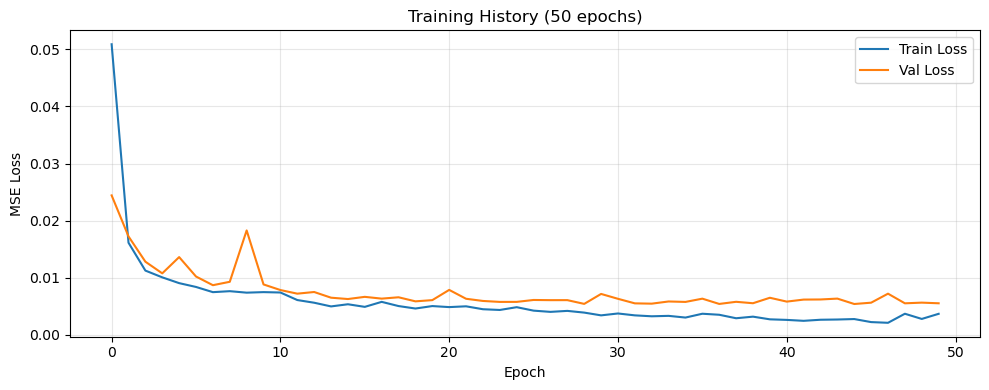


Best epoch: 45
Best val_loss: 0.005373


In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

epochs_run = len(history.history['loss'])
ax.plot(history.history['loss'], label='Train Loss')
ax.plot(history.history['val_loss'], label='Val Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title(f'Training History ({epochs_run} epochs)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBest epoch: {np.argmin(history.history['val_loss']) + 1}")
print(f"Best val_loss: {min(history.history['val_loss']):.6f}")

## 7. Test Prediction (Full Domain)

Load one test frame and predict on the full domain to verify the model works.

In [12]:
# Pick a test day: the last date in the record that was not used for training
# or validation, falling back to the final available day.
used = set(options.split.train_dates) | set(options.split.val_dates)
available = [str(pd.to_datetime(t).date()) for t in ds_std.time.values]
unused = [d for d in available if d not in used]
test_date = unused[-1] if unused else available[-1]
print(f"Test prediction date: {test_date}")

# Select and load test frame
ds_test = ds_std.sel(time=test_date).load()

# Stack channels in the resolved order.
X_test = np.stack(
    [np.nan_to_num(ds_test[ch].values, nan=0.0) for ch in options.data.input_names],
    axis=-1,
).astype('float32')
X_test = X_test[np.newaxis, ...]  # Add batch dimension

print(f"Test input shape: {X_test.shape}")

# Predict (fully-convolutional model handles any size)
y_pred = model(X_test, training=False).numpy()[0, :, :, 0]

# Unstandardize using the resolved target statistics.
y_pred_orig = y_pred * options.data.target_std + options.data.target_mean

print(f"Prediction shape: {y_pred_orig.shape}")
print(f"Prediction range: [{np.nanmin(y_pred_orig):.4f}, {np.nanmax(y_pred_orig):.4f}]")
print("\n\u2713 Model successfully predicts on full domain")

Test prediction date: 2000-12-31
Test input shape: (1, 168, 240, 9)
Prediction shape: (168, 240)
Prediction range: [-3.1411, 2.4081]

✓ Model successfully predicts on full domain


## Making a prediction

Currently the model does not use a custom loss and under clouds, the target is 0 (nan replaced with 0). So the model learns that if there is a real cloud (real_cloud_flag is 1) then predict 0 always. The model also learns that if synthetic _cloud = 0 and real_cloud = 0, then there is a value in masked_target and use that. If synthetic _cloud = 1 and real_cloud = 0, then there is always a 0 in masked_target (non-informative) so make an estimate from the other input variables. 

Soo, that means if we make a prediction from ds_test, it will have 0s whereever there are real clouds and it will only make estimates under the synthetic clouds.

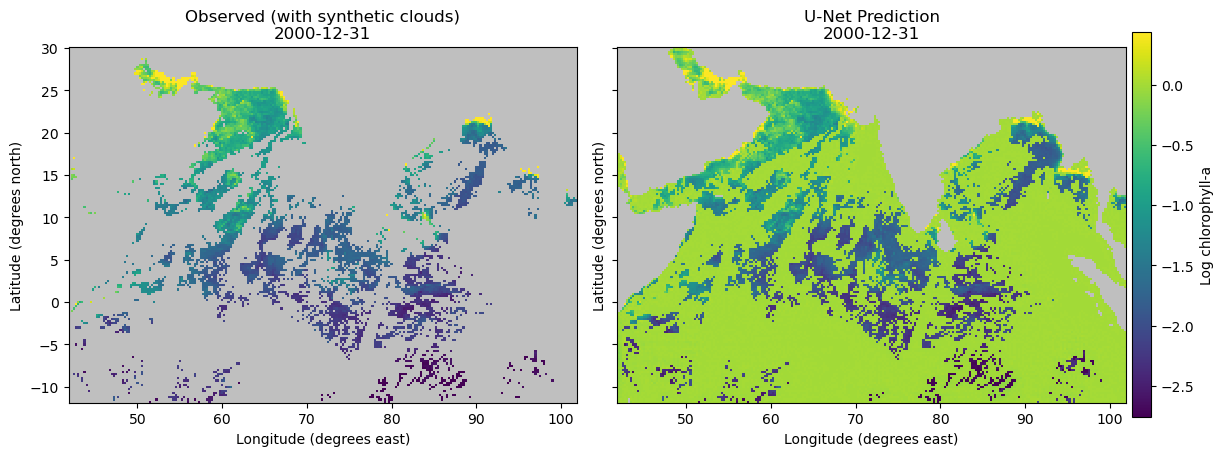

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

# Put observations in the same unstandardized units as the prediction.
observed = ds_test['masked_target'].values * options.data.target_std + options.data.target_mean
land = ds_test['land_flag'].values.astype(bool)
observed = np.ma.masked_where(land | ~np.isfinite(observed), observed)
prediction = np.ma.masked_where(land | ~np.isfinite(y_pred_orig), y_pred_orig)

# Use geographic coordinates and one robust scale for both panels.
vmin, vmax = np.nanpercentile(observed.filled(np.nan), [2, 98])
plot_kwargs = dict(cmap='viridis', shading='auto', vmin=vmin, vmax=vmax)
longitude = ds_test['lon'].values
latitude = ds_test['lat'].values

axes[0].set_facecolor('0.75')
axes[0].pcolormesh(longitude, latitude, observed, **plot_kwargs)
axes[0].set_title(f'Observed (with synthetic clouds)\n{test_date}')

axes[1].set_facecolor('0.75')
im = axes[1].pcolormesh(longitude, latitude, prediction, **plot_kwargs)
axes[1].set_title(f'U-Net Prediction\n{test_date}')

for ax in axes:
    ax.set_xlabel('Longitude (degrees east)')
    ax.set_ylabel('Latitude (degrees north)')
    ax.set_aspect('equal')

color_label = 'Log chlorophyll-a' if options.data.log_target else 'Chlorophyll-a'
plt.colorbar(im, ax=axes, label=color_label, fraction=0.02)
fig.subplots_adjust(wspace=0.08, right=0.88)
plt.show()


## 8. Save Model

Save the trained model for later use.

In [14]:
# Everything the bundle needs is already resolved on options.data, so the
# metadata and the fitting pipeline cannot diverge. Save the complete resolved
# Options with the bundle.
region = {"lat": list(options.data.lat_bounds), "lon": list(options.data.lon_bounds)}
bundle_path = Path("../models") / f"{dataset}-unet-bundle"
metadata_path = mtg.create_model_bundle_metadata(
    bundle_path,
    model_name=f"{options.data.source} U-Net gap filler",
    dataset_name=options.data.source,
    product_id=options.data.product_id,
    region=region,
    training_period=options.split.training_period(),
    input_names=options.data.input_names,
    target_name=options.data.target_name,
    target_units=options.data.target_units,
    expected_input_shape=list(model.input_shape),
    transforms=options.data.transforms,
    standardization=options.data.standardization,
    missing_value_handling=options.data.missing_value_handling,
    limitations=(
        "Validated only for the documented product, region, training period, "
        "channel order, and preprocessing configuration."
    ),
    options=options,
    overwrite=True,
)
print(f"Metadata saved to: {metadata_path}")


Metadata saved to: ../models/io-shared-public-unet-bundle/model_metadata.yaml


### Stop and review the metadata

Open the `model_metadata.yaml` file printed above. Check the dataset, region, training period, input channel order, transforms, and standardization values. **Do not run the next cell until the metadata is correct.**

In [15]:
mtg.save_model_bundle(
    model,
    bundle_path,
    overwrite=True,
)
print(f"✓ Model bundle saved to: {bundle_path}")

✓ Model bundle saved to: ../models/io-shared-public-unet-bundle


In [16]:
# Verify that the released artifact loads without rebuilding the U-Net.
loaded_model, loaded_metadata = mtg.load_model_bundle(bundle_path)
round_trip_input = X_test[:1]
expected = model(round_trip_input, training=False).numpy()
actual = loaded_model(round_trip_input, training=False).numpy()
np.testing.assert_allclose(actual, expected, rtol=1e-6, atol=1e-6)
assert [item["name"] for item in loaded_metadata["inputs"]] == options.data.input_names
print("✓ Bundle reload produced equivalent predictions")


✓ Bundle reload produced equivalent predictions
